# DINOv2 Dual-Task: Segmentation + Classification
## Breast Ultrasound (BUSI) Dataset
**Architecture:** DINOv2 ViT-B/14 backbone  
- **CLS token** → 3-class classification (benign / malignant / normal)  
- **Patch tokens** → decoded to binary segmentation mask  

Dataset format expected:
```
combined_breast_ultrasound_dataset/
├── benign/
│   ├── images/  (*.png, grayscale)
│   └── masks/   (*.png, binary)
├── malignant/
│   ├── images/
│   └── masks/
└── normal/
    ├── images/
    └── masks/
```

## 1. Install Dependencies

In [ ]:
# Run once — comment out after first run
# !pip install transformers timm albumentations segmentation-models-pytorch tqdm

## 2. Imports & Config

In [ ]:
import os
import re
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from transformers import Dinov2Model, Dinov2Config

from tqdm.notebook import tqdm
from tqdm import tqdm  # plain tqdm, no widgets needed

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [2]:
CFG = {
    # ── Dataset ──────────────────────────────────────────────────────────────
    "data_root": r"C:\Users\ASHAH\Desktop\DL_Project\breast_ultrasound\combined_breast_ultrasound_dataset",

    # ── Image ────────────────────────────────────────────────────────────────
    # DINOv2 ViT-B/14 uses patch_size=14. img_size must be divisible by 14.
    # 322 = 23 × 14  (close to original 320, zero-overhead for DINO)
    "img_size":    322,
    "patch_size":  14,      # fixed by DINOv2 architecture

    # ── Training ─────────────────────────────────────────────────────────────
    "batch_size":  8,
    "epochs":      50,
    "lr":          1e-4,    # lower LR — fine-tuning a pretrained ViT
    "encoder_lr":  1e-5,    # backbone gets 10× smaller LR (differential LR)
    "num_workers": 0,
    "weight_decay": 1e-4,

    # ── Model ────────────────────────────────────────────────────────────────
    "dino_model":  "facebook/dinov2-base",   # options: dinov2-small / dinov2-base / dinov2-large
    "num_classes": 3,          # benign, malignant, normal

    # ── Loss weights ─────────────────────────────────────────────────────────
    "cls_weight":  0.4,        # total_loss = seg_loss + cls_weight * cls_loss
    "threshold":   0.5,
}

# Label mapping (same as original notebook)
LABEL2IDX = {"benign": 0, "malignant": 1, "normal": 2}
IDX2LABEL  = {v: k for k, v in LABEL2IDX.items()}

# Derived constants
NUM_PATCHES = (CFG["img_size"] // CFG["patch_size"]) ** 2  # 23×23 = 529
PATCH_GRID  =  CFG["img_size"] // CFG["patch_size"]        # 23
print(f"Grid: {PATCH_GRID}×{PATCH_GRID} = {NUM_PATCHES} patches")

Grid: 23×23 = 529 patches


## 3. Dataset Loading (same structure as original notebook)

In [3]:
DATASET_ROOT = Path(CFG["data_root"])

rows = []
for cls_name in ["benign", "malignant", "normal"]:
    cls_dir  = DATASET_ROOT / cls_name
    img_dir  = cls_dir / "images"
    mask_dir = cls_dir / "masks"

    masks = {
        re.sub(r"_mask$", "", p.stem): str(p)
        for p in mask_dir.glob("*.png")
    }

    for img_path in sorted(img_dir.glob("*.png")):
        key = img_path.stem
        rows.append({
            "image_path": str(img_path),
            "mask_path":  masks.get(key, None),
            "label":      cls_name,
            "label_idx":  LABEL2IDX[cls_name],
        })

df = pd.DataFrame(rows)
print(df["label"].value_counts())
print("Total:", len(df))
print("With mask:", df["mask_path"].notna().sum())
print("Without mask:", df["mask_path"].isna().sum())

label
normal       729
benign       477
malignant    261
Name: count, dtype: int64
Total: 1467
With mask: 1467
Without mask: 0


In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Valid: {len(valid_df)}  |  Test: {len(test_df)}")

Train: 1026  |  Valid: 220  |  Test: 221


## 4. Augmentation Transforms

In [5]:
# DINOv2 was pretrained on RGB images with ImageNet mean/std.
# We replicate the grayscale channel 3× so it fits the pretrained weights.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.10,
        rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5
    ),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),
])

valid_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])

## 5. Dataset Class

> **Key difference from original:** images are converted from grayscale → 3-channel RGB by repeating the channel, then normalized with ImageNet statistics (required by DINOv2 pretrained weights).

image shape: torch.Size([3, 322, 322])
mask  shape: torch.Size([1, 322, 322])
label: malignant


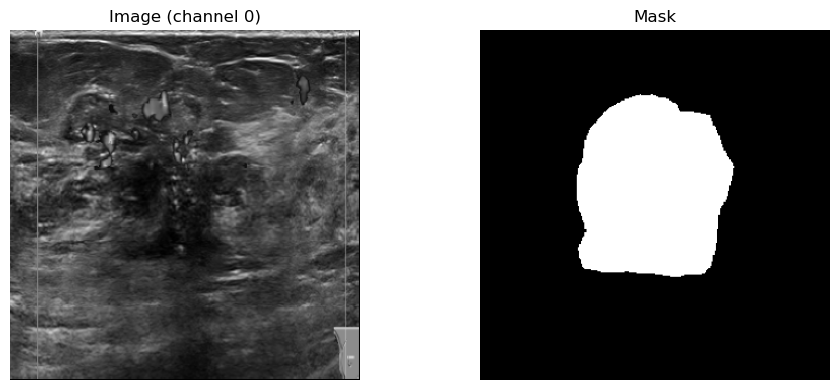

In [6]:
class BUSIDinoDataset(Dataset):
    """
    Same directory layout as original BUSISegDataset.
    Converts grayscale → 3-channel for DINOv2 backbone.
    Returns:
        image      : FloatTensor [3, H, W]  (ImageNet-normalised)
        mask       : FloatTensor [1, H, W]  (binary, 0/1)
        label      : str
        label_idx  : LongTensor scalar
    """
    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, df, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms
        self.H = CFG["img_size"]
        self.W = CFG["img_size"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Load image (grayscale) ──────────────────────────────────────────
        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Image not found: {row['image_path']}")

        # ── Load mask ───────────────────────────────────────────────────────
        mask_path = row["mask_path"]
        if mask_path and Path(mask_path).exists():
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros(image.shape, dtype=np.float32)

        # ── Resize ──────────────────────────────────────────────────────────
        image = cv2.resize(image, (self.W, self.H), interpolation=cv2.INTER_LINEAR)
        mask  = cv2.resize(mask,  (self.W, self.H), interpolation=cv2.INTER_NEAREST)

        # ── Augmentations (albumentations expects HWC for image) ────────────
        if self.transforms is not None:
            out   = self.transforms(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        # ── Grayscale → 3-channel (repeat channel) ──────────────────────────
        image = image.astype(np.float32) / 255.0          # [H, W]  in [0,1]
        image = np.stack([image, image, image], axis=-1)  # [H, W, 3]

        # ── ImageNet normalisation ───────────────────────────────────────────
        image = (image - self.MEAN) / self.STD             # [H, W, 3]

        # ── HWC → CHW ────────────────────────────────────────────────────────
        image = np.transpose(image, (2, 0, 1))             # [3, H, W]
        mask  = np.expand_dims(mask.astype(np.float32), 0) # [1, H, W]

        return {
            "image":     torch.tensor(image, dtype=torch.float32),
            "mask":      torch.tensor(mask,  dtype=torch.float32),
            "label":     row["label"],
            "label_idx": torch.tensor(row["label_idx"], dtype=torch.long),
        }


# ── Sanity-check a sample ────────────────────────────────────────────────────
_ds = BUSIDinoDataset(train_df, transforms=train_tfms)
_s  = _ds[0]
print("image shape:", _s["image"].shape)      # [3, 322, 322]
print("mask  shape:", _s["mask"].shape)       # [1, 322, 322]
print("label:",       _s["label"])

# Visualise
_img_vis = (_s["image"].numpy().transpose(1,2,0) * np.array([0.229,0.224,0.225]) +
             np.array([0.485,0.456,0.406])).clip(0,1)
_msk_vis = _s["mask"][0].numpy()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(_img_vis[:,:,0], cmap="gray"); ax[0].set_title("Image (channel 0)"); ax[0].axis("off")
ax[1].imshow(_msk_vis, cmap="gray");        ax[1].set_title("Mask");             ax[1].axis("off")
plt.tight_layout(); plt.show()

## 6. DINOv2 Dual-Task Model

```
Input [B, 3, H, W]
        │
   DINOv2 ViT-B/14 backbone
        │
   ┌────┴────────────────┐
   │                     │
 CLS token          Patch tokens
 [B, 768]          [B, N, 768]
   │                     │
 Cls Head          Seg Decoder
 (Linear)       (reshape + upsample)
   │                     │
[B, 3]           [B, 1, H, W]
```

**Segmentation decoder** — linear projection → reshape to (B, D', grid, grid) → 4× bilinear upsample → 1×1 conv to 1 channel. Lightweight on purpose: the ViT backbone already learns rich representations.

In [7]:
class SegDecoder(nn.Module):
    """
    Decodes DINOv2 patch tokens → binary segmentation mask.

    Steps:
      1. Linear projection: D → decode_dim  (reduces channel dim)
      2. Reshape: [B, N, D'] → [B, D', grid, grid]
      3. Progressive upsampling via ConvTranspose2d to reach original resolution
      4. Final 1×1 conv → 1 channel logit
    """
    def __init__(
        self,
        embed_dim:   int = 768,    # DINOv2-base hidden size
        decode_dim:  int = 256,
        patch_grid:  int = 23,     # img_size / patch_size = 322/14 = 23
        img_size:    int = 322,
    ):
        super().__init__()
        self.patch_grid = patch_grid
        self.img_size   = img_size

        # Channel projection
        self.proj = nn.Linear(embed_dim, decode_dim)
        self.norm = nn.LayerNorm(decode_dim)

        # Progressive upsample: 23 → 46 → 92 → 184 → 322 (bilinear + conv)
        self.up1 = self._up_block(decode_dim, 128)
        self.up2 = self._up_block(128, 64)
        self.up3 = self._up_block(64, 32)
        self.up4 = self._up_block(32, 16)

        # Final output — single-channel segmentation logit
        self.seg_head = nn.Conv2d(16, 1, kernel_size=1)

    @staticmethod
    def _up_block(in_ch, out_ch):
        """2× upsample followed by conv + BN + ReLU."""
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, patch_tokens, img_size):
        """
        patch_tokens : [B, N, D]  — N = patch_grid^2
        img_size     : int        — target output resolution
        returns      : [B, 1, img_size, img_size]
        """
        B, N, D = patch_tokens.shape
        g = self.patch_grid                         # 23

        x = self.norm(self.proj(patch_tokens))      # [B, N, decode_dim]
        x = x.transpose(1, 2).reshape(B, -1, g, g) # [B, decode_dim, 23, 23]

        x = self.up1(x)  # → [B, 128, 46, 46]
        x = self.up2(x)  # → [B,  64, 92, 92]
        x = self.up3(x)  # → [B,  32, 184, 184]
        x = self.up4(x)  # → [B,  16, 368, 368]

        # Bilinear resize to exact img_size (handles non-power-of-2 targets)
        x = F.interpolate(x, size=(img_size, img_size), mode="bilinear", align_corners=False)
        return self.seg_head(x)                     # [B, 1, H, W]


class DINODualTaskModel(nn.Module):
    """
    DINOv2 ViT backbone with:
      - Classification head on [CLS] token
      - Segmentation decoder on patch tokens

    Args:
        dino_model_name : HuggingFace model id, e.g. 'facebook/dinov2-base'
        num_classes     : number of classification classes
        patch_grid      : img_size // patch_size
        img_size        : input image resolution
        freeze_backbone : if True, only train heads (useful for quick prototyping)
    """
    def __init__(
        self,
        dino_model_name: str = "facebook/dinov2-base",
        num_classes:     int = 3,
        patch_grid:      int = 23,
        img_size:        int = 322,
        freeze_backbone: bool = False,
    ):
        super().__init__()
        self.img_size = img_size

        # ── Backbone ─────────────────────────────────────────────────────────
        self.backbone = Dinov2Model.from_pretrained(dino_model_name)
        embed_dim = self.backbone.config.hidden_size  # 768 for dinov2-base

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # ── Classification head (CLS token → num_classes) ───────────────────
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

        # ── Segmentation decoder (patch tokens → mask) ───────────────────────
        self.seg_decoder = SegDecoder(
            embed_dim=embed_dim,
            decode_dim=256,
            patch_grid=patch_grid,
            img_size=img_size,
        )

    def forward(self, pixel_values):
        """
        pixel_values : [B, 3, H, W]
        returns:
            seg_logits : [B, 1, H, W]   — raw logits (not sigmoid)
            cls_logits : [B, num_classes]
        """
        outputs = self.backbone(
            pixel_values=pixel_values,
            output_hidden_states=False,
        )
        # last_hidden_state: [B, 1 + N_patches, D]  (first token = CLS)
        hidden = outputs.last_hidden_state

        cls_token     = hidden[:, 0, :]   # [B, D]
        patch_tokens  = hidden[:, 1:, :]  # [B, N, D]

        seg_logits = self.seg_decoder(patch_tokens, self.img_size)  # [B,1,H,W]
        cls_logits = self.cls_head(cls_token)                       # [B, C]

        return seg_logits, cls_logits

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


# ── Shape sanity check ────────────────────────────────────────────────────────
print("Loading DINOv2 backbone (first run will download ~330MB)...")
_model = DINODualTaskModel(
    dino_model_name=CFG["dino_model"],
    num_classes=CFG["num_classes"],
    patch_grid=PATCH_GRID,
    img_size=CFG["img_size"],
).to(device)

_x = torch.randn(2, 3, CFG["img_size"], CFG["img_size"]).to(device)
with torch.no_grad():
    _seg, _cls = _model(_x)
print(f"Seg logits : {_seg.shape}  (expected [2, 1, {CFG['img_size']}, {CFG['img_size']}])")
print(f"Cls logits : {_cls.shape}  (expected [2, {CFG['num_classes']}])")

n_params = sum(p.numel() for p in _model.parameters()) / 1e6
n_train  = sum(p.numel() for p in _model.parameters() if p.requires_grad) / 1e6
print(f"Total params: {n_params:.1f}M  |  Trainable: {n_train:.1f}M")
del _x, _seg, _cls

Loading DINOv2 backbone (first run will download ~330MB)...


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Seg logits : torch.Size([2, 1, 322, 322])  (expected [2, 1, 322, 322])
Cls logits : torch.Size([2, 3])  (expected [2, 3])
Total params: 87.5M  |  Trainable: 87.5M


## 7. Loss Functions & Metrics

In [8]:
dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss_fn  = nn.BCEWithLogitsLoss()
ce_loss_fn   = nn.CrossEntropyLoss()


def compute_combined_loss(seg_logits, cls_logits, masks, labels):
    """
    Combined dual-task loss (identical structure to original notebook).
      seg_loss  = Dice + BCE  (binary segmentation)
      cls_loss  = CrossEntropy (3-class classification)
      total     = seg_loss + cls_weight * cls_loss
    """
    seg_loss = dice_loss_fn(seg_logits, masks) + bce_loss_fn(seg_logits, masks)
    cls_loss = ce_loss_fn(cls_logits, labels)
    total    = seg_loss + CFG["cls_weight"] * cls_loss
    return total, seg_loss, cls_loss


def dice_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()


def iou_score(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()


def cls_accuracy(cls_logits, labels):
    preds = cls_logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

## 8. DataLoaders

In [9]:
def make_loaders(train_tfms, val_tfms):
    train_ds = BUSIDinoDataset(train_df, transforms=train_tfms)
    valid_ds = BUSIDinoDataset(valid_df, transforms=val_tfms)
    test_ds  = BUSIDinoDataset(test_df,  transforms=val_tfms)

    train_loader = DataLoader(
        train_ds, batch_size=CFG["batch_size"],
        shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=CFG["batch_size"],
        shuffle=False, num_workers=CFG["num_workers"], pin_memory=True
    )
    test_loader = DataLoader(
        test_ds,  batch_size=CFG["batch_size"],
        shuffle=False, num_workers=0, pin_memory=True
    )
    print(f"train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")
    return train_loader, valid_loader, test_loader, valid_ds, test_ds


train_loader, valid_loader, test_loader, valid_ds, test_ds = make_loaders(
    train_tfms, valid_tfms
)

train=1026  valid=220  test=221


## 9. Optimizer — Differential Learning Rates

Backbone gets 10× smaller LR than the decoder/heads to preserve pretrained features.

In [10]:
def build_optimizer(model):
    backbone_params = list(model.backbone.parameters())
    head_params     = list(model.cls_head.parameters()) + \
                      list(model.seg_decoder.parameters())

    optimizer = AdamW([
        {"params": backbone_params, "lr": CFG["encoder_lr"],  "weight_decay": CFG["weight_decay"]},
        {"params": head_params,     "lr": CFG["lr"],          "weight_decay": CFG["weight_decay"]},
    ])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-7)
    return optimizer, scheduler

## 10. Training & Validation Loops

In [11]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    totals = {"loss": 0, "seg_loss": 0, "cls_loss": 0, "dice": 0, "iou": 0, "acc": 0}

    for batch in tqdm(loader, desc="Train", leave=False):
        imgs    = batch["image"].to(device)
        masks   = batch["mask"].to(device)
        labels  = batch["label_idx"].to(device)

        optimizer.zero_grad()
        seg_logits, cls_logits = model(imgs)

        loss, seg_l, cls_l = compute_combined_loss(seg_logits, cls_logits, masks, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(seg_logits, masks, CFG["threshold"])
        totals["iou"]      += iou_score(seg_logits, masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cls_logits, labels)

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def evaluate(model, loader, desc="Valid"):
    model.eval()
    totals = {"loss": 0, "seg_loss": 0, "cls_loss": 0, "dice": 0, "iou": 0, "acc": 0}

    for batch in tqdm(loader, desc=desc, leave=False):
        imgs   = batch["image"].to(device)
        masks  = batch["mask"].to(device)
        labels = batch["label_idx"].to(device)

        seg_logits, cls_logits = model(imgs)
        loss, seg_l, cls_l = compute_combined_loss(seg_logits, cls_logits, masks, labels)

        totals["loss"]     += loss.item()
        totals["seg_loss"] += seg_l.item()
        totals["cls_loss"] += cls_l.item()
        totals["dice"]     += dice_score(seg_logits, masks, CFG["threshold"])
        totals["iou"]      += iou_score(seg_logits, masks, CFG["threshold"])
        totals["acc"]      += cls_accuracy(cls_logits, labels)

    n = len(loader)
    return {k: v / n for k, v in totals.items()}

## 11. Full Training Run

> **Tip — Warm-up strategy (optional):**  
> The first 5 epochs freeze the backbone and only train the heads. After that the full network is fine-tuned. Uncomment the `freeze/unfreeze` block if you hit memory limits on Colab.

In [12]:
model     = _model   # already on device from shape check above
optimizer, scheduler = build_optimizer(model)

WARMUP_EPOCHS  = 5   # freeze backbone for first N epochs
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

history = []
best_dice = 0.0

for epoch in range(1, CFG["epochs"] + 1):

    # ── Optional backbone warm-up ────────────────────────────────────────────
    if epoch == 1:
        print(f"[Warm-up] Freezing backbone for {WARMUP_EPOCHS} epoch(s)")
        model.freeze_backbone()
    elif epoch == WARMUP_EPOCHS + 1:
        print("[Warm-up done] Unfreezing backbone — full fine-tune")
        model.unfreeze_backbone()

    # ── Train / validate ─────────────────────────────────────────────────────
    train_stats = train_one_epoch(model, train_loader, optimizer)
    valid_stats = evaluate(model, valid_loader, desc="Valid")
    scheduler.step()

    history.append({"epoch": epoch, **{f"train_{k}": v for k, v in train_stats.items()},
                                     **{f"valid_{k}": v for k, v in valid_stats.items()}})

    print(
        f"Ep {epoch:03d}/{CFG['epochs']}  "
        f"train_loss={train_stats['loss']:.4f}  dice={train_stats['dice']:.4f}  acc={train_stats['acc']:.4f}  "
        f"|| val_loss={valid_stats['loss']:.4f}  dice={valid_stats['dice']:.4f}  acc={valid_stats['acc']:.4f}"
    )

    # ── Best-model checkpoint ─────────────────────────────────────────────────
    if valid_stats["dice"] > best_dice:
        best_dice = valid_stats["dice"]
        torch.save(
            {"epoch": epoch, "state_dict": model.state_dict(),
             "dice": best_dice, "cfg": CFG},
            CHECKPOINT_DIR / "best_dino_dual.pth"
        )
        print(f"  ✓ Saved best checkpoint  (dice={best_dice:.4f})")

hist_df = pd.DataFrame(history) 
print("\nTraining complete. Best val Dice:", round(best_dice, 4))

[Warm-up] Freezing backbone for 5 epoch(s)


Train:   0%|          | 0/129 [00:00<?, ?it/s]

Valid:   0%|          | 0/28 [00:00<?, ?it/s]

Ep 001/50  train_loss=1.8074  dice=0.1977  acc=0.6066  || val_loss=1.7230  dice=0.2718  acc=0.6473
  ✓ Saved best checkpoint  (dice=0.2718)


Train:   0%|          | 0/129 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/28 [00:00<?, ?it/s]

Ep 049/50  train_loss=0.8349  dice=0.8896  acc=0.9409  || val_loss=1.0384  dice=0.8575  acc=0.8438


Train:   0%|          | 0/129 [00:00<?, ?it/s]

Valid:   0%|          | 0/28 [00:00<?, ?it/s]

Ep 050/50  train_loss=0.8381  dice=0.8878  acc=0.9302  || val_loss=1.0469  dice=0.8525  acc=0.8438

Training complete. Best val Dice: 0.8628


## 12. Training Curves

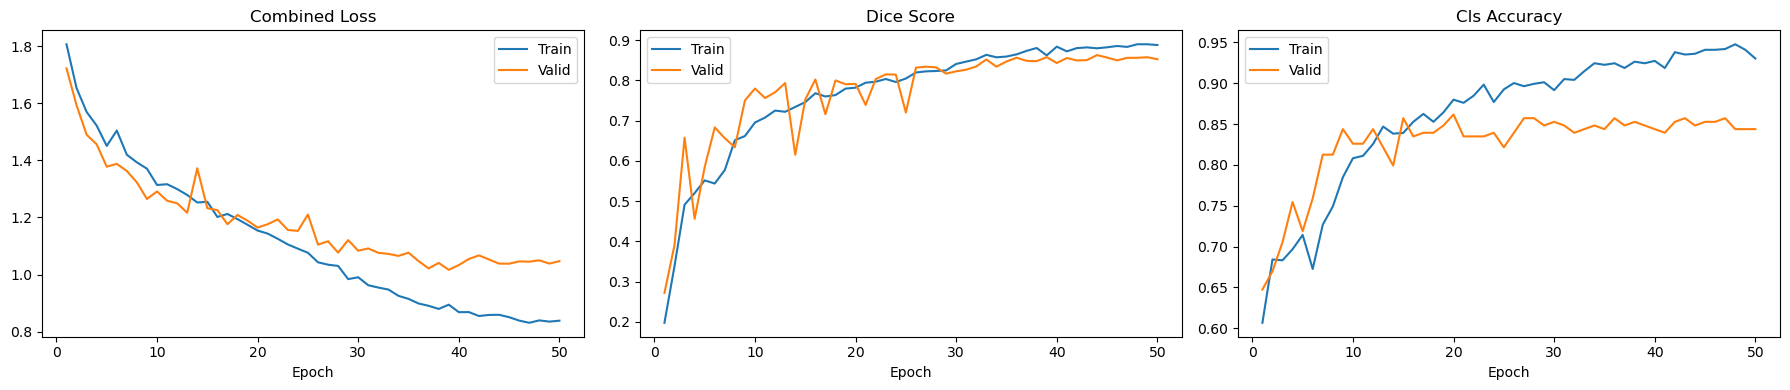

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Loss
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
axes[0].plot(hist_df["epoch"], hist_df["valid_loss"], label="Valid")
axes[0].set_title("Combined Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

# Dice
axes[1].plot(hist_df["epoch"], hist_df["train_dice"], label="Train")
axes[1].plot(hist_df["epoch"], hist_df["valid_dice"], label="Valid")
axes[1].set_title("Dice Score"); axes[1].legend(); axes[1].set_xlabel("Epoch")

# Accuracy
axes[2].plot(hist_df["epoch"], hist_df["train_acc"], label="Train")
axes[2].plot(hist_df["epoch"], hist_df["valid_acc"], label="Valid")
axes[2].set_title("Cls Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout(); plt.show()

## 13. Test Set Evaluation

In [14]:
# Load best checkpoint
ckpt = torch.load(CHECKPOINT_DIR / "best_dino_dual.pth", map_location=device)
model.load_state_dict(ckpt["state_dict"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val Dice={ckpt['dice']:.4f})")

test_stats = evaluate(model, test_loader, desc="Test")
print("\n=== Test Set Results ===")
for k, v in test_stats.items():
    print(f"  {k:12s}: {v:.4f}")

Loaded best checkpoint from epoch 44 (val Dice=0.8628)


Test:   0%|          | 0/28 [00:00<?, ?it/s]


=== Test Set Results ===
  loss        : 1.0334
  seg_loss    : 0.8037
  cls_loss    : 0.5742
  dice        : 0.8572
  iou         : 0.8083
  acc         : 0.8661


Predicting:   0%|          | 0/28 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.86      0.83        72
   malignant       0.94      0.77      0.85        39
      normal       0.89      0.90      0.90       110

    accuracy                           0.86       221
   macro avg       0.87      0.84      0.86       221
weighted avg       0.87      0.86      0.86       221



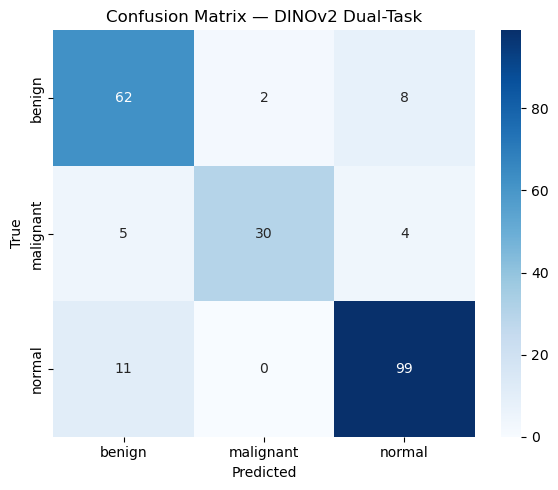

In [15]:
# ── Detailed classification report + confusion matrix ────────────────────────
all_preds, all_labels = [], []
model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        imgs   = batch["image"].to(device)
        labels = batch["label_idx"].cpu().numpy()
        _, cls_logits = model(imgs)
        preds = cls_logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[IDX2LABEL[i] for i in range(CFG["num_classes"])]
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[IDX2LABEL[i] for i in range(CFG["num_classes"])],
    yticklabels=[IDX2LABEL[i] for i in range(CFG["num_classes"])],
)
plt.title("Confusion Matrix — DINOv2 Dual-Task")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

## 14. Qualitative Visualisation — Predictions on Test Samples

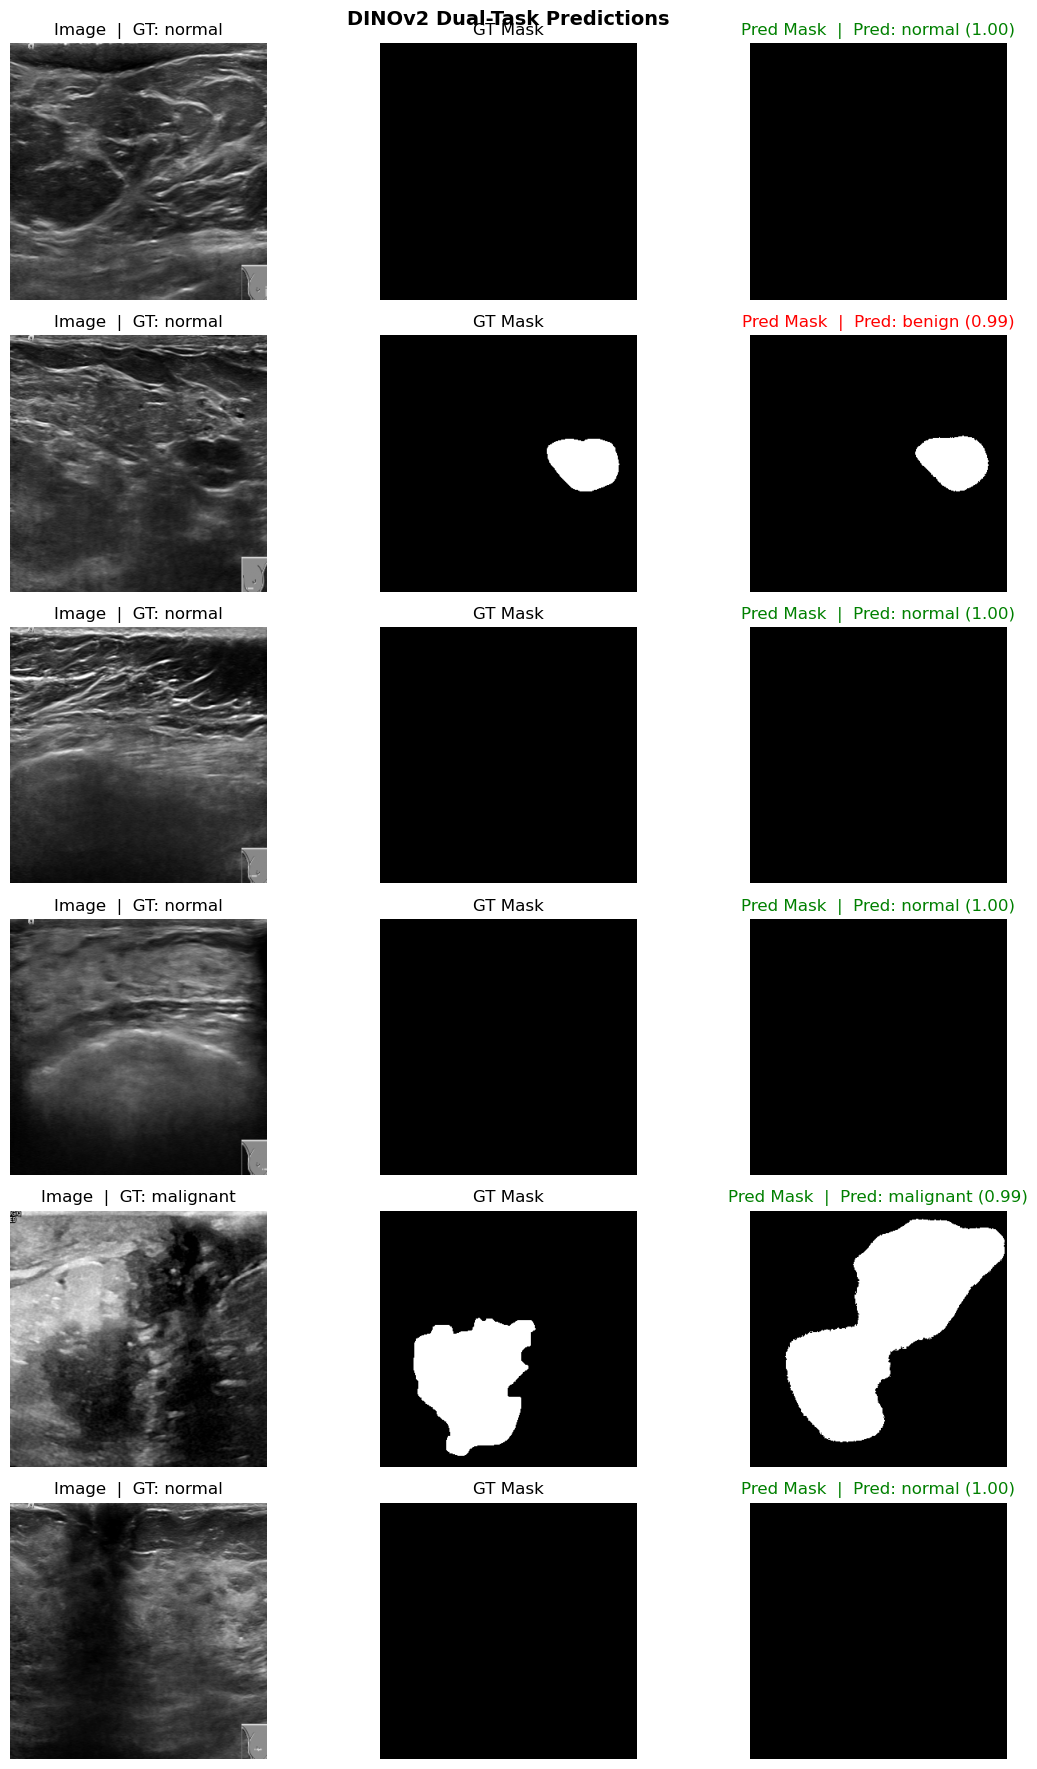

In [16]:
def denorm(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose(1, 2, 0)  # CHW → HWC
    img  = img * std + mean
    return img.clip(0, 1)[:, :, 0]  # take channel 0 (all 3 are identical)


model.eval()
n_show = 6
indices = np.random.choice(len(test_ds), n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 3))
fig.suptitle("DINOv2 Dual-Task Predictions", fontsize=14, fontweight="bold")

for row, idx in enumerate(indices):
    sample  = test_ds[idx]
    img_t   = sample["image"].unsqueeze(0).to(device)
    gt_mask = sample["mask"][0].numpy()
    gt_lbl  = sample["label"]

    with torch.no_grad():
        seg_logit, cls_logit = model(img_t)

    pred_mask  = (torch.sigmoid(seg_logit[0, 0]) > CFG["threshold"]).cpu().numpy().astype(float)
    pred_cls   = IDX2LABEL[cls_logit.argmax(dim=1).item()]
    confidence = torch.softmax(cls_logit, dim=1).max().item()

    img_vis = denorm(sample["image"])

    axes[row, 0].imshow(img_vis, cmap="gray")
    axes[row, 0].set_title(f"Image  |  GT: {gt_lbl}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask, cmap="gray")
    axes[row, 1].set_title("GT Mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask, cmap="gray")
    color = "green" if pred_cls == gt_lbl else "red"
    axes[row, 2].set_title(f"Pred Mask  |  Pred: {pred_cls} ({confidence:.2f})",
                            color=color)
    axes[row, 2].axis("off")

plt.tight_layout(); plt.show()

## 15. DINOv2 Attention Map Visualisation (Bonus)

DINOv2 [CLS] attention heads naturally highlight the lesion region — a powerful interpretability check.

In [17]:
def get_attention_maps(model, img_tensor):
    """
    Extract last-layer self-attention maps from DINOv2.
    Returns attention weights of shape [num_heads, N_patches, N_patches].
    """
    attentions = []

    def hook_fn(module, input, output):
        # output is (context_layer, attn_weights) for Dinov2 attention
        if isinstance(output, tuple) and len(output) == 2:
            attentions.append(output[1].detach().cpu())

    # Register hook on the last attention layer
    last_layer = model.backbone.encoder.layer[-1].attention.attention
    handle = last_layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model.backbone(pixel_values=img_tensor, output_attentions=True)

    handle.remove()
    return attentions[0] if attentions else None  # [1, heads, N+1, N+1]


sample  = test_ds[0]
img_t   = sample["image"].unsqueeze(0).to(device)
img_vis = denorm(sample["image"])

# Use output_attentions from backbone directly (HuggingFace API)
model.eval()
with torch.no_grad():
    out = model.backbone(pixel_values=img_t, output_attentions=True)

# attentions: list of tensors [1, heads, N+1, N+1] per layer
last_attn = out.attentions[-1][0]          # [heads, N+1, N+1]
cls_attn  = last_attn[:, 0, 1:]            # [heads, N]  — CLS attends to patches
cls_attn  = cls_attn.mean(0)               # [N]  — avg over heads
cls_attn  = cls_attn.reshape(PATCH_GRID, PATCH_GRID).cpu().numpy()

# Upsample to image resolution
attn_map = cv2.resize(cls_attn, (CFG["img_size"], CFG["img_size"]),
                      interpolation=cv2.INTER_LINEAR)
attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_vis, cmap="gray");              axes[0].set_title("Image");              axes[0].axis("off")
axes[1].imshow(sample["mask"][0], cmap="gray");   axes[1].set_title("GT Mask");            axes[1].axis("off")
axes[2].imshow(img_vis, cmap="gray")
axes[2].imshow(attn_map, cmap="jet", alpha=0.5);  axes[2].set_title("DINO Attention Map"); axes[2].axis("off")
plt.suptitle(f"Label: {sample['label']}", fontsize=13)
plt.tight_layout(); plt.show()

IndexError: tuple index out of range

---
## Architecture Summary

| Component | Details |
|---|---|
| Backbone | DINOv2 ViT-B/14 (`facebook/dinov2-base`) |
| Input | 322×322 px, grayscale → 3-channel repeat, ImageNet normalised |
| Patch grid | 23×23 = 529 patches |
| Classification | CLS token → LayerNorm → Linear(768,512) → GELU → Dropout → Linear(512,3) |
| Segmentation | Patch tokens → Linear proj → reshape [B,256,23,23] → 4× ConvTranspose → bilinear resize → Conv(16,1) |
| Loss | Dice + BCE (seg) + 0.4 × CE (cls) |
| Optimizer | AdamW, differential LR: backbone 1e-5, heads 1e-4 |
| Scheduler | CosineAnnealingLR |
| Warm-up | 5 epochs with frozen backbone, then full fine-tune |